# Big Data Analysis Project
Group members:
- Lourenço Passeiro 20221838
- Miguel Marques 20221839
- Peter Lekszycki 20221840
- Tomás Gonçalves 20221894

# **Inaugural Speeches Analysis**

Inaugural speeches have always been a key moment for U.S. presidents, offering a chance to start a connection with the American people and set the tone for their time in office. Some presidents are remembered for their soaring, poetic language, while others keep it simple and to the point. 

Over time, the lexic is constantly evolving, leaving some words behind while welcoming others. Given this, have the way presidents speak and choose words changed dramatically? 


**ML Cluster required, with the following libraries installed:**

- "spark-nlp==5.3.3" on PyPi
- "com.johnsnowlabs.nlp:spark-nlp_2.12:5.3.3" on Maven

### Imports and installations:

In [0]:
# Must install
%pip install sparknlp
%pip install --upgrade Pillow
%pip install wordcloud matplotlib
%pip install nltk pyspark

Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.


In [0]:
# Imports:

import sparknlp
spark = sparknlp.start()

from sparknlp.base import DocumentAssembler, Pipeline, LightPipeline
from sparknlp.annotator import (
    Tokenizer,
    WordEmbeddingsModel,
    NerDLModel,
    NerConverter
)

import pyspark.sql.functions as F

import string

from wordcloud import WordCloud
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [0]:
baseRdd = sc.textFile("/FileStore/inaug_speeches.csv")
baseDf = spark.read.csv("/FileStore/inaug_speeches.csv", header=True, inferSchema=True)

### Word Count & Map Reduce

In [0]:
baseRdd.count()

59

The dataset contain 59 inaugural speeches, with several presidents having multiple speeches (as they served multiple terms).

In [0]:
baseRdd.take(2)

['"","Name","Inaugural Address","Date","text"',
 '"4","George Washington","First Inaugural Address","Thursday, April 30, 1789","           Fellow-Citizens of the Senate and of the House of Representatives:  ��AMONG the vicissitudes incident to life no event could have filled me with greater anxieties than that of which the notification was transmitted by your order, and received on the   th day of the present month. On the one hand, I was summoned by my country, whose voice I can never hear but with veneration and love, from a retreat which I had chosen with the fondest predilection, and, in my flattering hopes, with an immutable decision, as the asylum of my declining years<U+0097>a retreat which was rendered every day more necessary as well as more dear to me by the addition of habit to inclination, and of frequent interruptions in my health to the gradual waste committed on it by time. On the other hand, the magnitude and difficulty of the trust to which the voice of my country call

Firstly, we need to split every record by the delimiter (comma in this case).

In [0]:
splitRdd = baseRdd.map(lambda line: line.split(","))
splitRdd.take(2)

[['""', '"Name"', '"Inaugural Address"', '"Date"', '"text"'],
 ['"4"',
  '"George Washington"',
  '"First Inaugural Address"',
  '"Thursday',
  ' April 30',
  ' 1789"',
  '"           Fellow-Citizens of the Senate and of the House of Representatives:  ��AMONG the vicissitudes incident to life no event could have filled me with greater anxieties than that of which the notification was transmitted by your order',
  ' and received on the   th day of the present month. On the one hand',
  ' I was summoned by my country',
  ' whose voice I can never hear but with veneration and love',
  ' from a retreat which I had chosen with the fondest predilection',
  ' and',
  ' in my flattering hopes',
  ' with an immutable decision',
  ' as the asylum of my declining years<U+0097>a retreat which was rendered every day more necessary as well as more dear to me by the addition of habit to inclination',
  ' and of frequent interruptions in my health to the gradual waste committed on it by time. On the o

Now let's choose 5 presidents to analyse!
- George Washington
- Abraham Lincoln
- Franklin D. Roosevelt
- Ronald Reagan
- Donald Trump

First, we need to extract every word of every speech:

In [0]:
def token_extracter_rdd(president_name):
  """Extracts every token from every speech of a given president"""
  return splitRdd  \
    .filter(lambda x: x[1] == president_name)  \
    .map(lambda x: x[6:])    \
    .flatMap(lambda row: row)   \
    .flatMap(lambda field: field.split())

In [0]:
# Applying token extracter to each president
washington_words = token_extracter_rdd('"George Washington"')
lincoln_words = token_extracter_rdd('"Abraham Lincoln"')
roosevelt_words = token_extracter_rdd('"Franklin D. Roosevelt"')
reagan_words = token_extracter_rdd('"Ronald Reagan"')
trump_words = token_extracter_rdd('"Donald J. Trump"')

Now we must clean the tokens, by removing punctuation, making everything lower case, and then removing white spaces. Chaining the transformations in this specific order leads to a cleaner text.

In [0]:
def token_cleaner(token_rdd):
  """Cleans every word list of words"""
  return token_rdd \
    .map(lambda word: word.translate(str.maketrans('', '', string.punctuation+"�"))) \
    .map(lambda word: str(word).lower()) \
    .filter(lambda word: len(word) > 0)

In [0]:
# Applying word cleaner to each president
washington_clean_words = token_cleaner(washington_words)
lincoln_clean_words = token_cleaner(lincoln_words)
roosevelt_clean_words = token_cleaner(roosevelt_words)
reagan_clean_words = token_cleaner(reagan_words)
trump_clean_words = token_cleaner(trump_words)

In [0]:
roosevelt_words.take(7)

['"', '��I', 'AM', 'certain', 'that', 'my', 'fellow']

In [0]:
roosevelt_clean_words.take(6)

['i', 'am', 'certain', 'that', 'my', 'fellow']

With every word cleaned, we now can proceed to the MapReduce part:

In [0]:
def map_reducer(clean_rdd):
  """ Given a RDD of words, performs MapReduce """
  return clean_rdd \
    .map(lambda word: (word, 1)) \
    .reduceByKey(lambda a, b: a + b)

In [0]:
# Applying the map reducer to each president's cleaned words
washington_mr = map_reducer(washington_clean_words)
lincoln_mr = map_reducer(lincoln_clean_words)
roosevelt_mr = map_reducer(roosevelt_clean_words)
reagan_mr = map_reducer(reagan_clean_words)
trump_mr = map_reducer(trump_clean_words)

Now that we got the frequencies of every word on the speeches, let's compare the presidents:

In [0]:
print(f"Washington's most frequent words: {washington_mr.filter(lambda x : x[1] >= 45).collect()} ")
print(f"Lincoln's most frequent words: {lincoln_mr.filter(lambda x : x[1] >= 100).collect()}" )
print(f"Roosevelt's most frequent words: {roosevelt_mr.filter(lambda x : x[1] >= 150).collect()}" )
print(f"Reagan's most frequent words: {reagan_mr.filter(lambda x : x[1] >= 120).collect()}" )
print(f"Trump's most frequent words: {trump_mr.filter(lambda x : x[1] >= 45).collect()}" )

Washington's most frequent words: [('of', 82), ('the', 129), ('and', 50), ('to', 53)] 
Lincoln's most frequent words: [('of', 168), ('the', 314), ('to', 160), ('and', 129)]
Roosevelt's most frequent words: [('of', 319), ('the', 371), ('and', 176), ('to', 153)]
Reagan's most frequent words: [('of', 185), ('we', 124), ('and', 201), ('to', 152), ('the', 251)]
Trump's most frequent words: [('of', 48), ('we', 48), ('and', 75), ('the', 71), ('our', 47)]


It seems that the more frequent words are the same for all presidents. Weird? No, because it consists of stopwords - basic, functional words essential for sentence structure but carry minimal unique meaning, such as articles, prepositions, and conjunctions. In order to get a better view of the speeches, we will remove them!

In [0]:
# Get the list of English stopwords
stop_words = stopwords.words('english')

# Best performance with broadcast
stop_words_broadcast = sc.broadcast( set(stop_words) )

In [0]:
print(stop_words)

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

In [0]:
def stopword_remover(word_rdd):
  """ Given a RDD of words it keeps only the non-stopwords """
  return word_rdd \
    .filter(lambda pair: pair[0] not in stop_words_broadcast.value) 


In [0]:
# Applying the stopword remover
washington_nosw = stopword_remover(washington_mr)
lincoln_nosw = stopword_remover(lincoln_mr)
roosevelt_nosw = stopword_remover(roosevelt_mr)
reagan_nosw = stopword_remover(reagan_mr)
trump_nosw = stopword_remover(trump_mr)

In [0]:
print(f"Washington's most frequent words: {washington_nosw.filter(lambda x : x[1] >= 6).collect()} ")
print(f"Lincoln's most frequent words: {lincoln_nosw.filter(lambda x : x[1] >= 20).collect()}" )
print(f"Roosevelt's most frequent words: {roosevelt_nosw.filter(lambda x : x[1] >= 20).collect()}" )
print(f"Reagan's most frequent words: {reagan_nosw.filter(lambda x : x[1] >= 22).collect()}" )
print(f"Trump's most frequent words: {trump_nosw.filter(lambda x : x[1] >= 7).collect()}" )

Washington's most frequent words: [('country', 6), ('public', 6), ('may', 7), ('present', 6), ('every', 9), ('government', 9), ('shall', 6)] 
Lincoln's most frequent words: [('constitution', 22), ('people', 20), ('shall', 22), ('union', 24)]
Roosevelt's most frequent words: [('nation', 26), ('us', 20), ('people', 26), ('government', 22), ('shall', 20)]
Reagan's most frequent words: [('us', 51), ('world', 23), ('must', 22), ('people', 25), ('government', 27)]
Trump's most frequent words: [('america', 19), ('country', 9), ('people', 10), ('every', 7), ('one', 8), ('american', 11)]


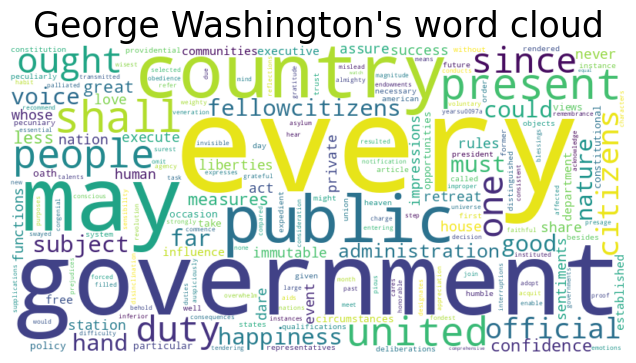

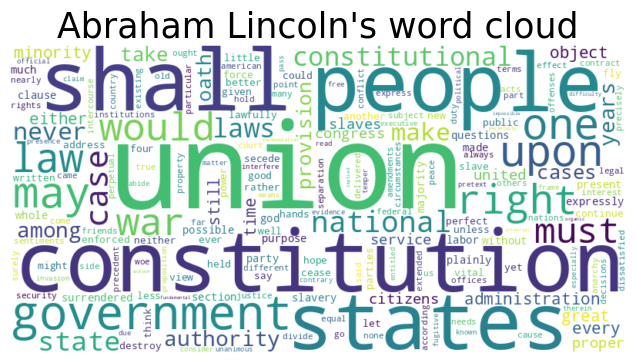

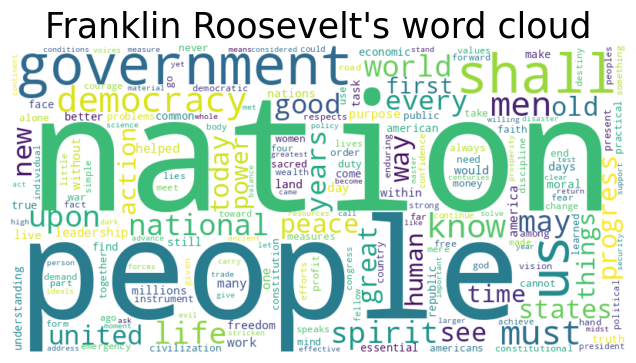

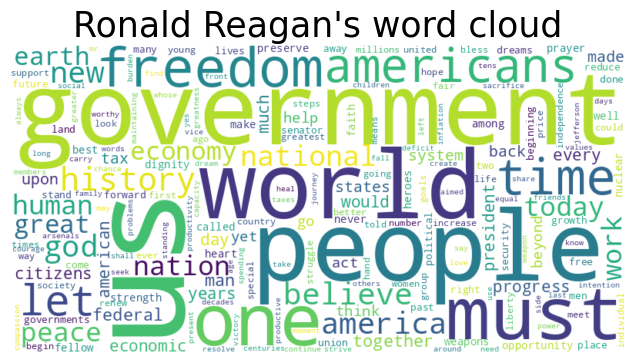

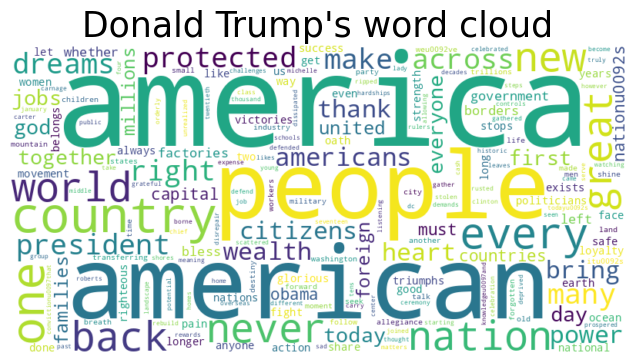

In [0]:
presidents = ["George Washington", "Abraham Lincoln", "Franklin Roosevelt", "Ronald Reagan", "Donald Trump"]
mr_nosw_rdds = [washington_nosw, lincoln_nosw, roosevelt_nosw, reagan_nosw, trump_nosw]

for president, rdd in zip(presidents, mr_nosw_rdds):
  word_freq = dict(rdd.takeOrdered(200, key=lambda x: -x[1])) # Filtering to get only the top 200 words as it is the maximum that WC takes
  wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies( word_freq )

  plt.figure(figsize=(8, 4))
  plt.title(f"{president}'s word cloud", fontsize=25)
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off') 
  plt.show()

### Extra: Name-Entity Recognition#

In [0]:
# Converting raw text to document format
documenter = DocumentAssembler()\
    .setInputCol("clean_text")\
    .setOutputCol("document")

# Tokenization
tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("tokenized")

# Getting the embeddings using GloVe
embeddings = WordEmbeddingsModel.pretrained("glove_100d").\
                  setInputCols(["document", "tokenized"]).\
                  setOutputCol("embeddings")

# Using a pre-trained NER model
ner_model = NerDLModel.pretrained("ner_dl", "en") \
          .setInputCols(["document", "tokenized", "embeddings"]) \
          .setOutputCol("ner")

# Convert to NER tags
ner_converter = NerConverter() \
                .setInputCols(["document", "tokenized", "ner"]) \
                  .setOutputCol("entities")

# Define a pipeline with all the steps above
ner_pipeline = Pipeline(stages=[ documenter, 
                                 tokenizer,
                                 embeddings,
                                 ner_model,
                                 ner_converter
                                 ])

glove_100d download started this may take some time.
Approximate size to download 145.3 MB
[OK!]
ner_dl download started this may take some time.
Approximate size to download 13.6 MB
[OK!]


In [0]:
def filter_and_clean(president_name):
    """ Filters the speech of a given president and cleans it"""
    return baseDf \
              .filter(F.col("Name") == president_name) \
              .withColumn("clean_text", regexp_replace("text", "�", "")) \
              .select("clean_text")

In [0]:
washington_df = filter_and_clean("George Washington")
lincoln_df = filter_and_clean("Abraham Lincoln")
roosevelt_df = filter_and_clean("Franklin D. Roosevelt")
reagan_df = filter_and_clean("Ronald Reagan")
trump_df = filter_and_clean("Donald J. Trump")

In [0]:
def ner_apply(df):
  """ Apply the name-entity recognition defined pipeline to a given dataframe """
  ner_pipeline_model = ner_pipeline.fit(df)

  results = ner_pipeline_model \
              .transform(df) \
              .select(F.col("ner")) \
              .withColumn("ner_exploded", F.explode("ner")) \
              .withColumns({
                  "result":  F.col("ner_exploded.result"), 
                  "metadata": F.col("ner_exploded.metadata.word") 
                          }) \
              .select(F.col("result"), F.col("metadata"))

  return results

In [0]:
# Applying the NER pipeline to each president
washington_ner = ner_apply(washington_df)
lincoln_ner = ner_apply(lincoln_df)
roosevelt_ner = ner_apply(roosevelt_df)
reagan_ner = ner_apply(reagan_df)
trump_ner = ner_apply(trump_df)

In [0]:
trump_ner.groupBy("result").count().display()

result,count
B-MISC,21
I-LOC,8
B-PER,16
O,1565
I-MISC,2
B-LOC,24
I-PER,4


In [0]:
roosevelt_ner.filter(F.col("result") == "B-LOC").display()

result,metadata
B-LOC,Nation
B-LOC,States
B-LOC,United
B-LOC,Nation
B-LOC,United
B-LOC,Nation
B-LOC,Republic
B-LOC,Republic
B-LOC,Republic
B-LOC,States


The results that the NER pipeline gave us were pretty bad, and we were not able to extract any meaningful insights from there. This probably happened due to the type of words usually used in a inaugural speech, where there are not many mentions to entities excepting ex-presidents.